# 6. Post-process light curves

In this notebook we show how you easily can get a quick-look on your `PlatoSim` simulations and perform a simple post-processing steps to get your final merged light curve.

Note that to run this notebook, you need to have the Python dependencies from the `platonium` toolkit installed (e.g. `poetry install --with platonium`).

Last tested version: `PlatoSim 3.7.0-165-gae316c48`

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [3]:
# Python standard
import os
import sys
import glob

# PlatoSim standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# PlatoSim functions
import platosim.utilities as ut  
from platosim.lightcurve   import LightCurve
from platosim.utilities    import getFunctions
from platosim.matplotlibrc import setup_notebook
setup_notebook()

# Configure notebook 
from IPython.display import display, HTML
display(HTML("<style>.container {width:60% !important; }</style>"))

---
## Introduction
---

When scripting in Python while analysing your PlatoSim simulations, it can be very useful to use the two PlatoSim paths that you have globally exported (the latter in particular since your simulations is saved to the working directory by default):

In [4]:
hdir = os.getenv('PLATO_PROJECT_HOME')
hdir

'/lhome/nicholas/software/PlatoSim3'

In [7]:
wdir = os.getenv('PLATO_WORKDIR')
wdir

'/lhome/nicholas/software/workdir/'

To be completely independent on operation system, we further use `pathlib.Path` objects. E.g. let's define the directory for which all data of this tutorial is stored:

In [8]:
path = Path(wdir) / 'quicklook'
idir = path / 'input'
sdir = path / 'simulations'
vdir = path / 'varsource'

In this tutotial we assume that you have used `platonium` to generate a batch of simulated light curves for one target star covering each camera and mission quarter. Thus, we download one such example to your working directory under the project called `quicklook`:

In [356]:
zipfile = f'{sdir.stem}/.zip'
ut.downloadFromFTP(zipfile, path, server='platodata')

To visualise and/or reduce your data, PlatoSim provides the Python class called `LightCurve`. This class has two "modes": a `single` mode to load only one 90-d camera light curve, and a `multi` mode to hadle all light curves simulated per target star. The methods of the `LightCurve` class can found with:

In [357]:
getFunctions(LightCurve)

LightCurve functions
__del__
__init__
_unit_add
_unit_convert
_units
axes_mask_updates
axes_quarter_marks
bin
bin_1d
bin_lc


We note that some of these are still being tested and validated. The methods shown in this notebook have been thoroughly tested.

Throughout this notebook we look at a few variable stars of the type $\gamma$ Doradus, showing low-amplitude low-frequency gravity modes. The `simulation` folder contains a target folder with ID 1002. This folder contains the multi-camera and multi-quarter light curves for 12 N-CAMs and a duration of 2 years (i.e. 8 mission quarters). This leave us with 96 simulated 90-day light curves per star that we can analyse in the follwoing. 

Since `platonium` returns 9-digit folders and filenames, we need to secure this structure using:

In [358]:
source =f'{1002}'.zfill(9)
source

'000001002'

---
## Single mode
---

We start with creating a `LightCurve` object, loading in the first light curve in the `data/mocka` folder:

In [359]:
G, C, Q = 2, 5, 1
lc = LightCurve(sdir / source/ f'{source}_Ncam{G}.{C}_Q{Q}.hdf5', mode='single')

### Obs information

When extracting data for a specific file, it can be useful to quickly fetch the `(group, camera, quarter)` IDs that you used to launch `platonium`. You can fetch this information easily with the method `obs()`:

In [360]:
lc.obs()

(2, 5, 1)

For each mission quarter simulation, a `.table` file is generated containing a small overview of the specific simulation. We can see the inforamtion for one such table with the `star()` method:

In [361]:
lc.star().T

,0
ID,1002
gaiaDR3,5591274943754084352
ra,112.800397
dec,-34.932931
mag,10.929007
group,2
camera,5
quarter,1
ccd,3
xCCD,208.881137


The table displays among others the CCD ID (`ccd`), the pixel positions (`xCCD` and `yCCD`), the focal plane coordinates (`xFP` and `yFP` in mm), the number of stellar contaminants (`ncon`), and stellar pollution ratio (`SPR`).

### Input variable model

Since we have the same file structure for our `varsource` path (only containing subfolders with the source ID), we can fetch the correct variable source file containing the injected signal simply by using:

In [362]:
lc.varsource().head()

,time,dmag,flux
0,0.0,0.000049,0.999955
1,25.0,0.000049,0.999955
2,50.0,0.000049,0.999955
3,75.0,0.000050,0.999954
4,100.0,0.000050,0.999954


Here the time is in seconds and the delta-magnitude and flux are both relative estimates. As seen in the following, the injected signal will be visualised directly by each plotting method due to our unique file structure.

### Fetch data

With the `lc` object we can fetch the time series, or the time [sec] and flux [e-/s] column independently:

In [363]:
lc.data().head()

,time,flux
0,12.5,8093.057678
1,37.5,8116.291511
2,62.5,8133.398704
3,87.5,8107.888699
4,112.5,8102.900169


In [364]:
lc.time().head()

0     12.5
1     37.5
2     62.5
3     87.5
4    112.5
Name: time, dtype: float64

In [365]:
lc.flux().head()

0    8093.057678
1    8116.291511
2    8133.398704
3    8107.888699
4    8102.900169
Name: flux, dtype: float64

### Visualise data

We can plot the light curve with the method `plot()` and for example show the 1-hour bins of the time series:

<IPython.core.display.Javascript object>


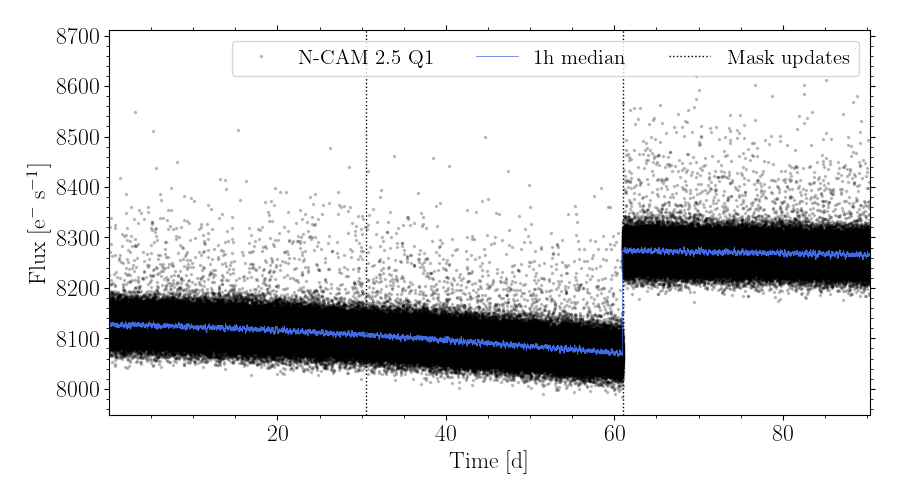

In [366]:
fig, ax = lc.plot(median_filter=1)

### Post-processing

In case of flux jumps (e.g. due to mask updates), you can sticth the light curve with the method `stitch()`:

<IPython.core.display.Javascript object>


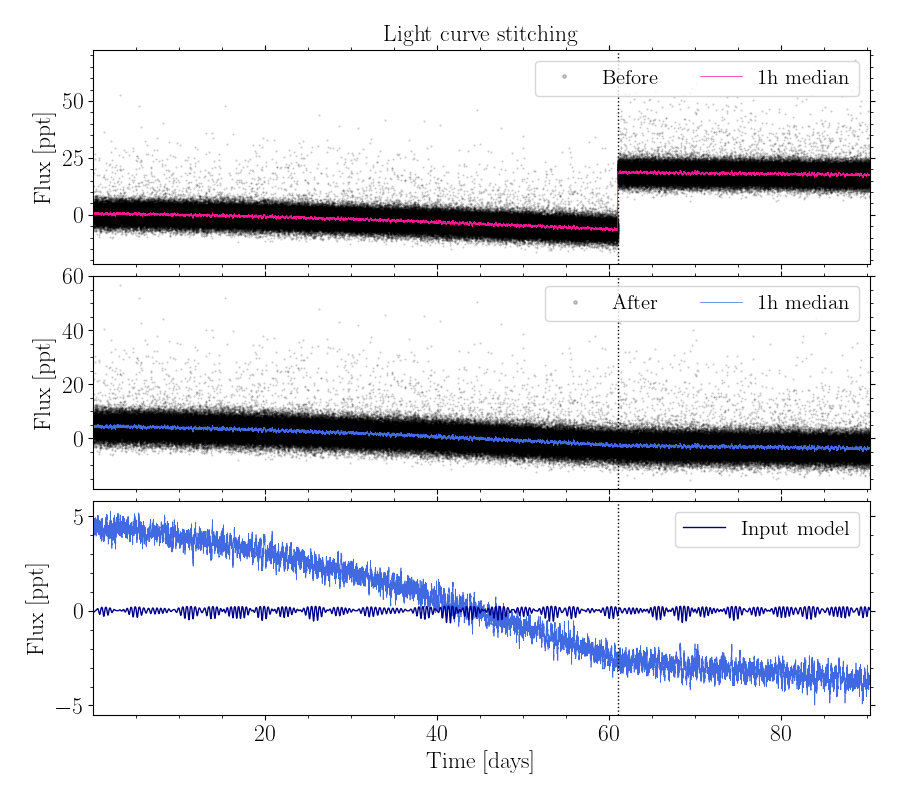

In [367]:
df = lc.stitch(segment=2, replace=False, plot=True)

Since detrending normally should remove flux jumps, we do not use the stitching from above in the following. 

You can detrend the light curve (in segments of each mask-update) with the method `detrend()`. Due to the vast amount of data, a general rule is that a simply polynomial detrending is sufficient if the long-term systematic trend dominates over intrinsic variability. For our low-amplitude pulsators this is the case. Using the `poly` detrend option, a simple model ($\Delta$BIC) comparison is performed for which the polynomial degree to use for each light curve segment between two mask updates (30-d or 60-d segments) or a full quarter light curve (90-d segment). Which degree used per segment is printed above the plot:

Detrending with 3-order polynomial
Detrending with 1-order polynomial


<IPython.core.display.Javascript object>


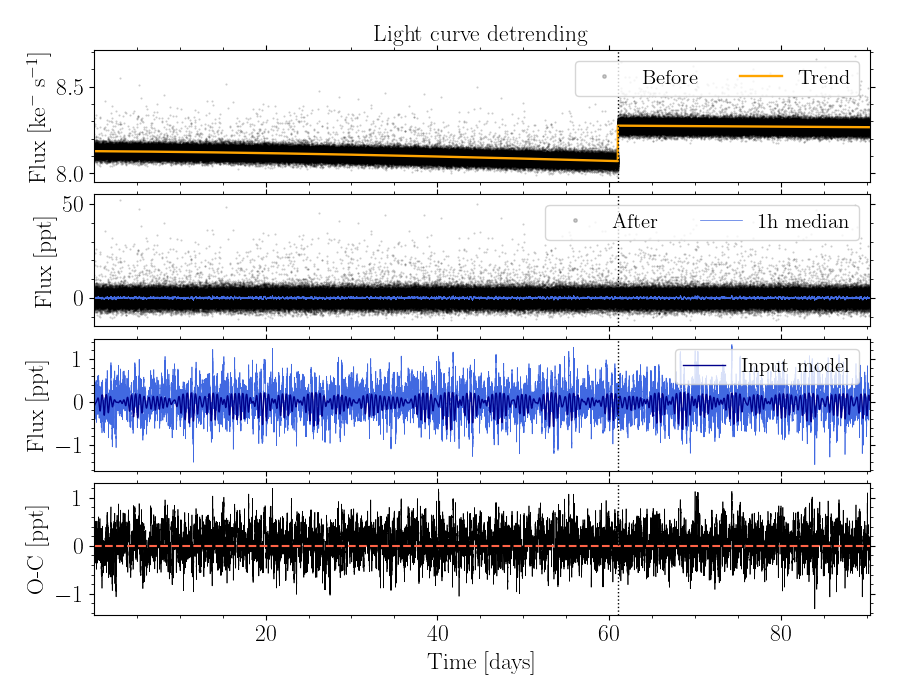

In [368]:
df = lc.detrend(model='poly', segments=True, replace=True, plot=True)

You can remove outliers (due to photon noise and cosmic ray hits) using the `clip()` method:

<IPython.core.display.Javascript object>


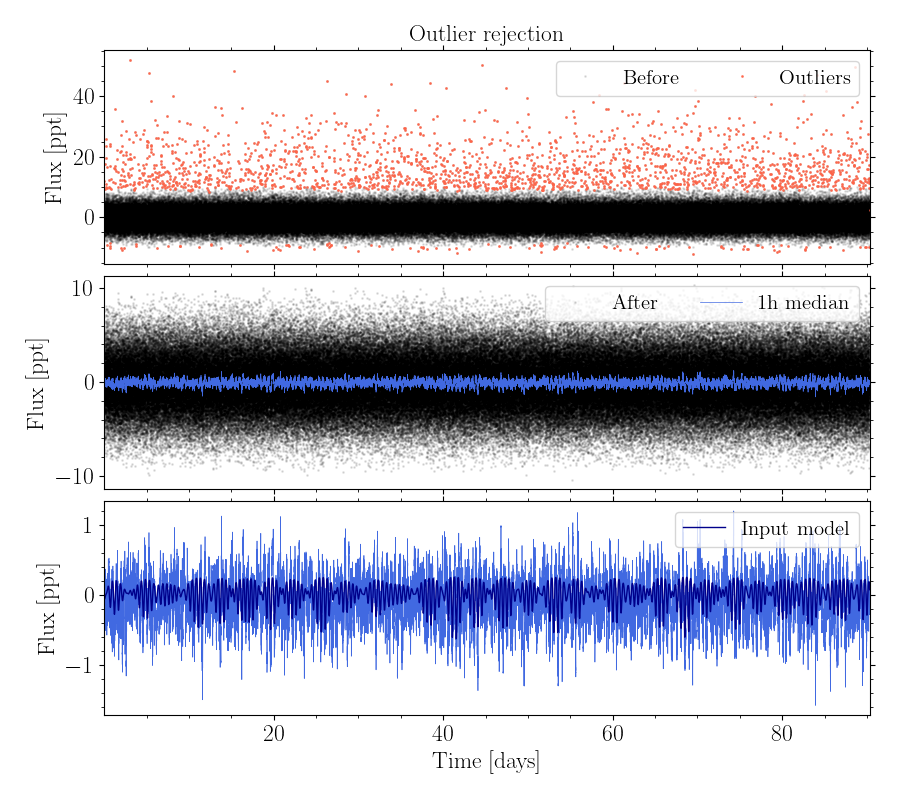

In [369]:
df = lc.clip(model='wotan', sigma_lower=3, sigma_upper=3, plot=True, flux_unit='ppt')

You can compute the error on each measurement using the method `flux_error()` which follows the methodology of Handberg & Lund (2014). This function takes a `short_filter`, `long_filter`, and a `type_filter` to determine the intricsic noise of the light curve (that is, it also include any error that the post-processing may have added in the previous steps). Here we try a -min short moving median filter ($m_i$), a 5-min long moving standard deviation filter (specified by `type_filter`, $m_j$): 

<IPython.core.display.Javascript object>


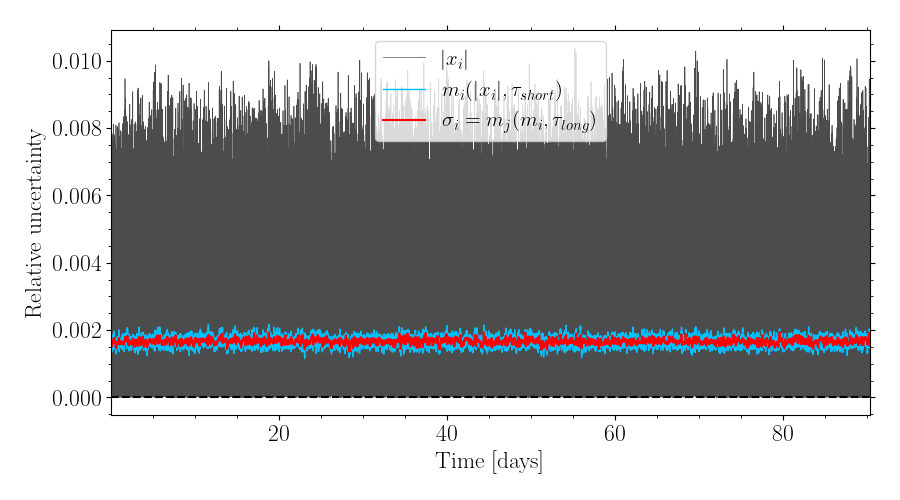

In [370]:
df = lc.flux_error(short_filter=2/60, long_filter=5/60, type_filter=np.std, plot=True)

Let's plot the resulting light curve with error bars:

<IPython.core.display.Javascript object>


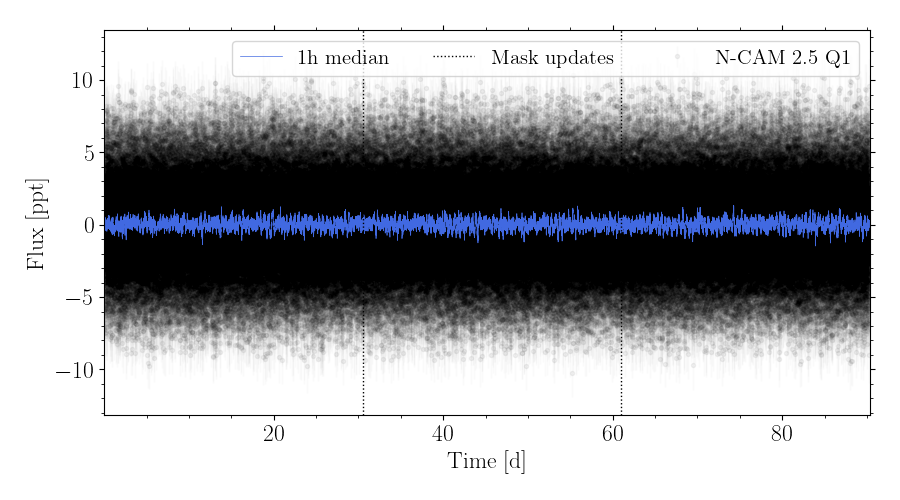

In [371]:
lc.plot(flux_unit='ppt', flux_error=True, median_filter=1, alpha=0.05);

### Auxilary data

To analyse the noise level in a ligth curve a few options are available. The first is the Noise-to-Signal Ratio (NSR) defined by:

$$
{\rm NSR}_{\rm 1h} = \frac{10^6}{\sqrt{144}}\frac{\sigma_F}{\bar{F}} \,,
$$

with the factor $10^6$ and 144 (=3600s/25s) returning NSR in ppm over an hour: 

In [372]:
lc.get_nsr()

230.08720240945408

Seen above, the light curve often include aperture mask updates. You can fetch the index of when these happens using the `mask_update_events()` method:

In [373]:
lc.mask_update_events()

array([     0, 105409, 210818], dtype=uint32)

---
## Multi mode
---

Initialise the `LightCurve` object and check about light curves we have for this target:

In [374]:
lcs = LightCurve(sdir / source, mode='multi')
files = lcs.files(suffix='hdf5')
len(files)

96

### Simulation statistics

From the single-mode we have seen the information stored in each simulation table. However, instead of having 96 individual files, it is much handier to have a single file to search information from. Let's save this file to:

In [375]:
ofile_table = sdir / f'table_{source}.ftr'
ofile_table

PosixPath('/lhome/nicholas/software/workdir/workshop2025/simulations/table_000001002.ftr')

We can then merge all sim-tables to one single overview table and save it to a feather file on disk with the method `stat_sim_table()`:

In [376]:
df = lcs.stat_sim_table(ofile=ofile_table, clean=False)
df.head()

,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,1002,5591274943754084352,112.800397,-34.932931,10.929007,1,1,1,3,3475.588591,1925.992705,17.864149,63.860595,-47.812131,3,0.025257
1,1002,5591274943754084352,112.800397,-34.932931,10.929007,1,1,2,2,226.566716,2084.356436,10.367231,-44.961584,-5.378201,3,0.026570
2,1002,5591274943754084352,112.800397,-34.932931,10.929007,1,1,5,3,3475.694905,1925.892626,17.864697,63.862508,-47.813933,3,0.025080
3,1002,5591274943754084352,112.800397,-34.932931,10.929007,1,1,6,2,226.459830,2084.581174,10.366280,-44.957539,-5.376277,3,0.026164
4,1002,5591274943754084352,112.800397,-34.932931,10.929007,1,2,1,3,3486.658135,1938.546626,17.869315,64.059846,-47.586161,3,0.025048


It possible to remove the (96) redundant `*.table` files during the process using `clean=True`, however, to avoid deleting them for this tutorial we set this argument to `False`.

### Visualise light curves

A tip is to use the multi-mode and simply investigate a certain light curve using `files` containing a list of filenames. For example we can fetch the first file and plot it using:

<IPython.core.display.Javascript object>


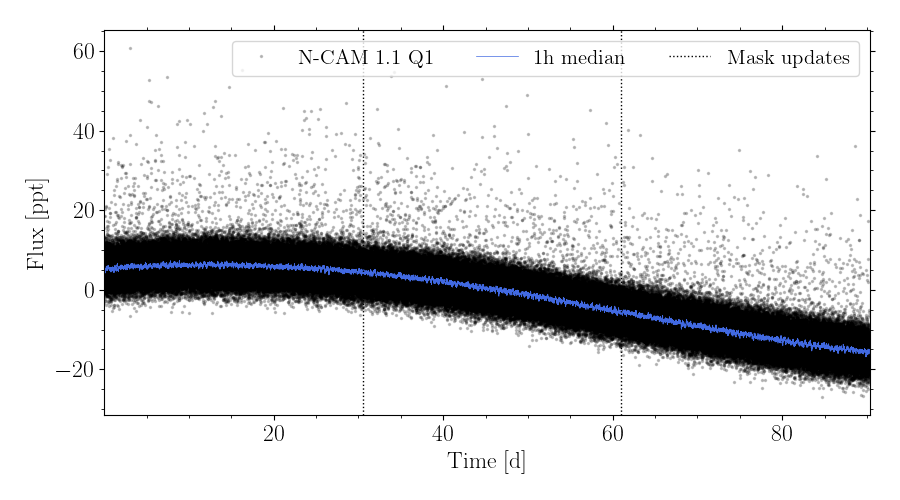

In [377]:
lc = LightCurve(files[0], mode="single")
fig, ax = lc.plot(flux_unit='ppt', median_filter=1)

The power of the multi-mode is that we can plot all light curve coherently together to investigate the simulations. The method called `plot_multi()` takes the `group`, `camera`, and `quarter` as input, allowing you to show different configurations of the observation. Let's plot first all light curves observed by camera ID 1 (across all camera groups):

<IPython.core.display.Javascript object>


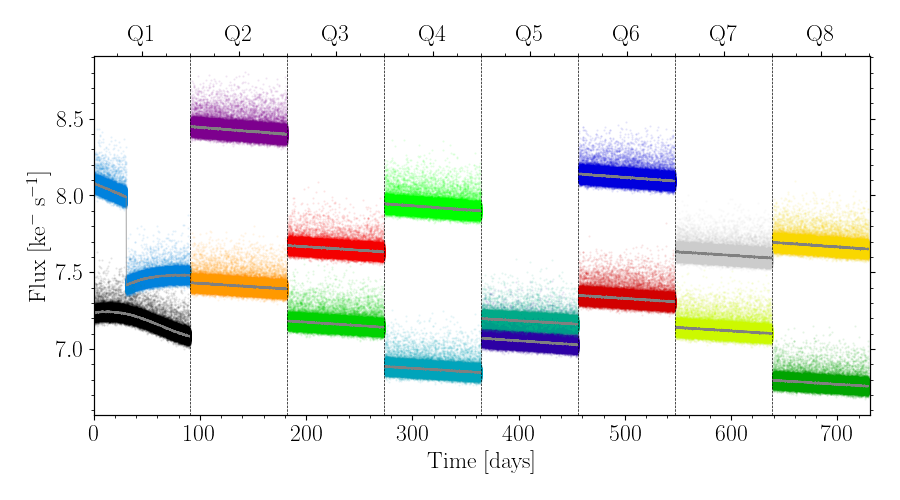

In [378]:
fig, ax = lcs.plot_multi(suffix='hdf5', group=False, camera=1, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

Let's plot all light curves and compare (be patient):

<IPython.core.display.Javascript object>


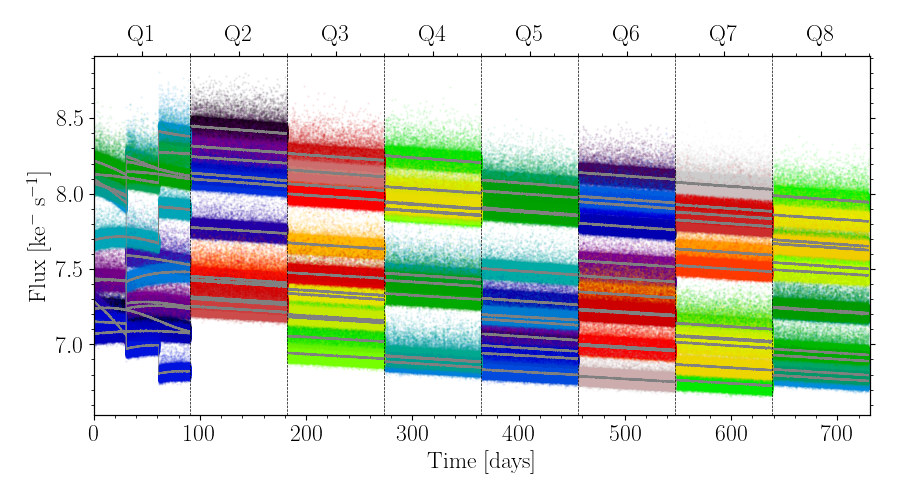

In [379]:
fig, ax = lcs.plot_multi(suffix='hdf5', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

You may have noticed the flux "jumps" happening in particarly in Q1. Triggered by aperture mask-updates by the on-board photometry algorith (allowed to happen every 30 days), the underlying cause is related to an orbital instability of the spacecraft in its early stage (whihc PlatoSim model with a realisitc lissajour-orbit file).   

### Post-processing

We provide a simple option to fully reduce your light curves and merge them into a final light curve using the post-processing step we presented above and at a cadence of 10 minutes. We do this with the `merge()` method while saving the output light curve to the file `ofile_lightcurve`: 

In [380]:
ofile_lightcurve = sdir / f'lc_{source}.ftr'

In [381]:
lc = lcs.merge(
    verbose=True,
    suffix='hdf5', 
    detrend='poly',
    flux_group_mean=True,
    binsize=600, # [s]
    clip_sigma=3,
    flux_offset=True, 
    flux_error=True,
    ofile=ofile_lightcurve,
)

Processing star ID 000001002
-------------------------------------------------------
Merging 96 light curves


100%|██████████████████████████████████████████████████| 96/96 [00:45<00:00,  2.10it/s]                                                                                                                     


Sorting data after timings
Averaging data from same camera group
Binning data per 600s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:01:01.326797 [h:mm:ss]
-------------------------------------------------------


As the above method returns a light curve object, we can use this to make the usual plot:

<IPython.core.display.Javascript object>


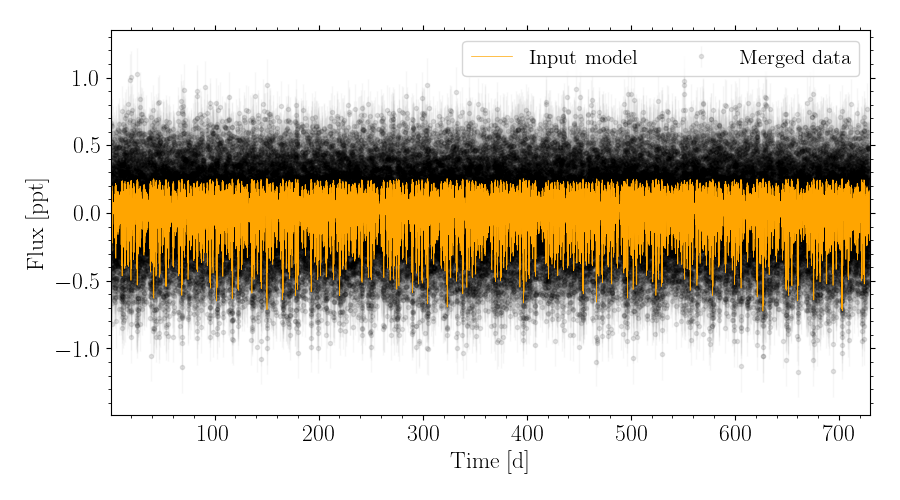

In [382]:
lc.plot(flux_unit='ppt', input_model=True, flux_error=True, alpha=0.1, figsize=(9,5));

Since `platonium` by default only simulate a 1-day data gap between mission quarters, we can include a more realistic distribution of down-times using the file `instrumentGAP.tab` and parse this file to the method `gaps()`:

In [383]:
df = lc.gaps(idir / 'instrumentGAP.tab', replace=True)
df.head()

,time,flux,flux_err
0,312.502053,0.999847,0.000196
1,912.506158,0.999887,0.000196
2,1512.510263,0.999803,0.000196
3,2112.514369,1.000164,0.000196
4,2712.518474,0.999876,0.000196


Let's see the data gaps implemented into the final light curve:

<IPython.core.display.Javascript object>


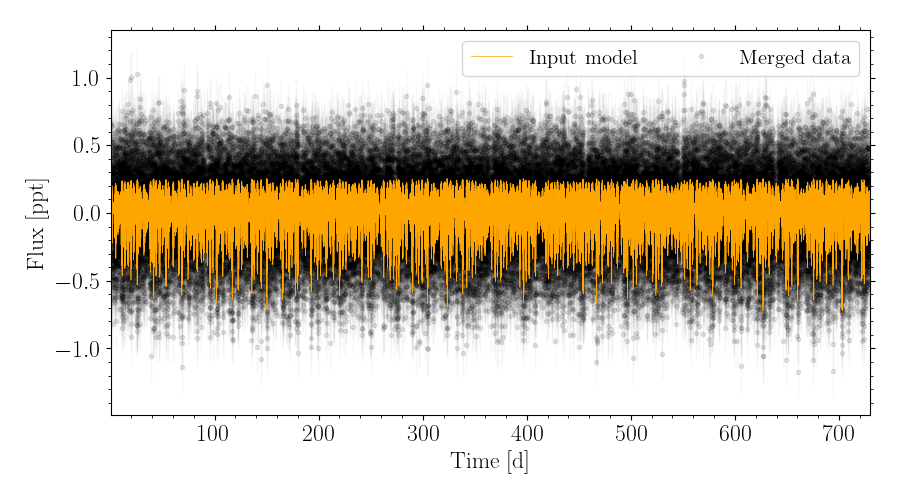

In [384]:
lc.plot(flux_unit='ppt', input_model=True, flux_error=True, alpha=0.1, figsize=(9,5));

Aside that each inter-mission quarter now last between 1.5 to 2.5 days, a few down-times duw to safe-mode events of the spacecraft have also be inlcuded (for example around 260 days and 510 days).

That's it! Have fun generating and analysing your own PLATOnium simulations!